# **IBL - Processed Widefield Imaging Data**

This tutorial shows how to access processed widefield data from [DANDI:001712](https://dandiarchive.org/dandiset/001712/draft) for the IBL widefield dataset.

## Study Overview

This dataset contains widefield imaging data from mice, investigating how prior expectations and neural dynamics are modified in a mouse model of autism (CNTNALP2 knockout). The study explores sensory perception and decision-making tasks to understand the neural basis of altered prior utilization.

The `desc-processed` NWB file contains:
- SVD-compressed spatial components (U, stored as `PlaneSegmentation` image masks)
- Haemodynamic-corrected and uncorrected temporal coefficients (SVT, stored as `RoiResponseSeries`)
- Mean fluorescence images per channel (stored as `GrayscaleImage` inside `Images`)
- Synchronization signals and behavior
- Atlas registration and anatomical coordinates (see also `anatomical_localization_tutorial.ipynb`)

## NWB object map

| Data | NWB location |
|---|---|
| Spatial components (U) | `ophys["SVDSpatialComponents"]["SVDTemporalComponentsCalcium"]["image_mask"]` |
| Temporal components — haemo-corrected | `ophys["SVDTemporalComponents"]["HaemoCorrectedSVDTemporalComponentsCalcium"]` |
| Temporal components — uncorrected calcium | `ophys["SVDTemporalComponents"]["DenoisedSVDTemporalComponentsCalcium"]` |
| Temporal components — isosbestic | `ophys["SVDTemporalComponents"]["DenoisedSVDTemporalComponentsIsosbestic"]` |
| Mean images | `ophys["Images"]["MeanImage"]`, `ophys["Images"]["MeanImageIsosbestic"]` |

## Contents

1. [Setup and Data Access](#setup)
2. [Session and Subject Metadata](#metadata)
3. [Processed Imaging Data and Metadata](#processed)
   - [SVD Temporal Components](#temporal-components)
   - [SVD Spatial Components](#spatial-components)
      - [Frame reconstruction](#reconstruct)
   - [Summary Images](#summary-images)
4. [Landmarks and Atlas Alignment](#landmarks)
5. [Behavior](#behavior)
   - [Epochs (Task vs Passive)](#epochs)
   - [Trials](#trials)
   - [Passive Data](#passive)
   - [Lick Times](#lick-times)
   - [Pupil](#pupil)
   - [ROI Motion Energy](#motion-energy)
   - [Wheel](#wheel)
   - [Pose Estimation](#pose-estimation)

---

# 1. Setup and Data Access <a id="setup"></a>

## Import Required Libraries

In [3]:
# Visualization
import matplotlib.pyplot as plt
import numpy as np


# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [4]:
from ibl_widefield_to_nwb.widefield2025.tutorials.load_nwb_utils import *

dandiset_id = "001712"
subject_id = "FD-28"  # Example subject
session_id = "81f90b18-e61c-4d32-bbce-3e0c5f33f06c"  # EID for the session

# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id, description="processed")
else:
    # Specify your local directory path
    local_directory = f"E:/IBL-widefield-nwbfiles/full"
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id, description="processed")

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 In dynamic environments, updating beliefs based on past experiences (priors) is essential for optimal decision-making. Prior utilization is often impaired in psychiatric disorders, affecting perception and behavior. We investigate how Neurexin1α (Nrxn1α) loss-of-function disrupts this process, providing insight into circuit deficits underlying sensorimotor dysfunction. While the synaptic role of Nrxn1α is well studied, its impact on network dynamics and decision-making behavior remain unclear. Using widefield calcium imaging, we assess cortex-wide activity in mice performing a two-choice task to probe how priors influence visually-guided decisions. This task requires the mouse to combine sensory evidence with the prior probability over the stimulus side. We find Nrxn1α KO mice underutilized priors and were slower to update choices based on feedback. During decision-making, cortex-wide cortical activity is both elevated and increasing

---

# 2. Session and Subject Metadata <a id="metadata"></a>

In [5]:
print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

print("\n=== SUBJECT INFORMATION ===")
print(f"ID: {nwbfile.subject.subject_id}")
print(f"DOB: {nwbfile.subject.date_of_birth}")
print(f"Strain: {nwbfile.subject.species}")
print(f"Genotype: {nwbfile.subject.genotype}")
print(f"Sex: {nwbfile.subject.sex}")

=== SESSION INFORMATION ===
Experiment description:
 In dynamic environments, updating beliefs based on past experiences (priors) is essential for optimal decision-making. Prior utilization is often impaired in psychiatric disorders, affecting perception and behavior. We investigate how Neurexin1α (Nrxn1α) loss-of-function disrupts this process, providing insight into circuit deficits underlying sensorimotor dysfunction. While the synaptic role of Nrxn1α is well studied, its impact on network dynamics and decision-making behavior remain unclear. Using widefield calcium imaging, we assess cortex-wide activity in mice performing a two-choice task to probe how priors influence visually-guided decisions. This task requires the mouse to combine sensory evidence with the prior probability over the stimulus side. We find Nrxn1α KO mice underutilized priors and were slower to update choices based on feedback. During decision-making, cortex-wide cortical activity is both elevated and increasing

---

## 3. Processed Imaging Data <a id="svd"></a>

Processed widefield data uses Singular Value Decomposition (SVD) to compress the video into spatial components **U** and temporal coefficients **SVT**.

In [6]:
ophys = nwbfile.processing["ophys"]

print("=== ophys processing module ===")
for name, obj in ophys.data_interfaces.items():
    print(f"  {name!r:45s}  ({type(obj).__name__})")

=== ophys processing module ===
  'Images'                                       (Images)
  'SVDSpatialComponents'                         (ImageSegmentation)
  'SVDTemporalComponents'                        (Fluorescence)


### Spatial Components (U) <a id="spatial"></a>

Spatial components are stored as image masks inside two `PlaneSegmentation` tables,
one per channel, both in `ophys["SVDSpatialComponents"]`.

| PlaneSegmentation | Channel |
|---|---|
| `SVDTemporalComponentsCalcium` | 470 nm (GCaMP) |
| `SVDTemporalComponentsIsosbestic` | 405 nm (isosbestic) |

In [7]:
image_segmentation = ophys["SVDSpatialComponents"]

print("=== Spatial Components ===")
print("-" * 100)
for _, plane_segmentation in image_segmentation.plane_segmentations.items():
    print(f"Plane Segmentation: {plane_segmentation.name}")
    print("-" * 100)
    print(f"   Description        : {plane_segmentation.description}")
    print(f"   Linked imaging plane: {plane_segmentation.imaging_plane.name}")
    print(f"   ROI properties      : {plane_segmentation.colnames}")
    print("-" * 100)

=== Spatial Components ===
----------------------------------------------------------------------------------------------------
Plane Segmentation: SVDTemporalComponentsCalcium
----------------------------------------------------------------------------------------------------
   Description        : Spatial components for widefield calcium imaging.
   Linked imaging plane: ImagingPlaneCalcium
   ROI properties      : ('roi_name', 'image_mask')
----------------------------------------------------------------------------------------------------
Plane Segmentation: SVDTemporalComponentsIsosbestic
----------------------------------------------------------------------------------------------------
   Description        : Spatial components for widefield calcium imaging.
   Linked imaging plane: ImagingPlaneIsosbestic
   ROI properties      : ('roi_name', 'image_mask')
----------------------------------------------------------------------------------------------------


U_calcium shape : (200, 540, 640)  → (n_components, height, width)


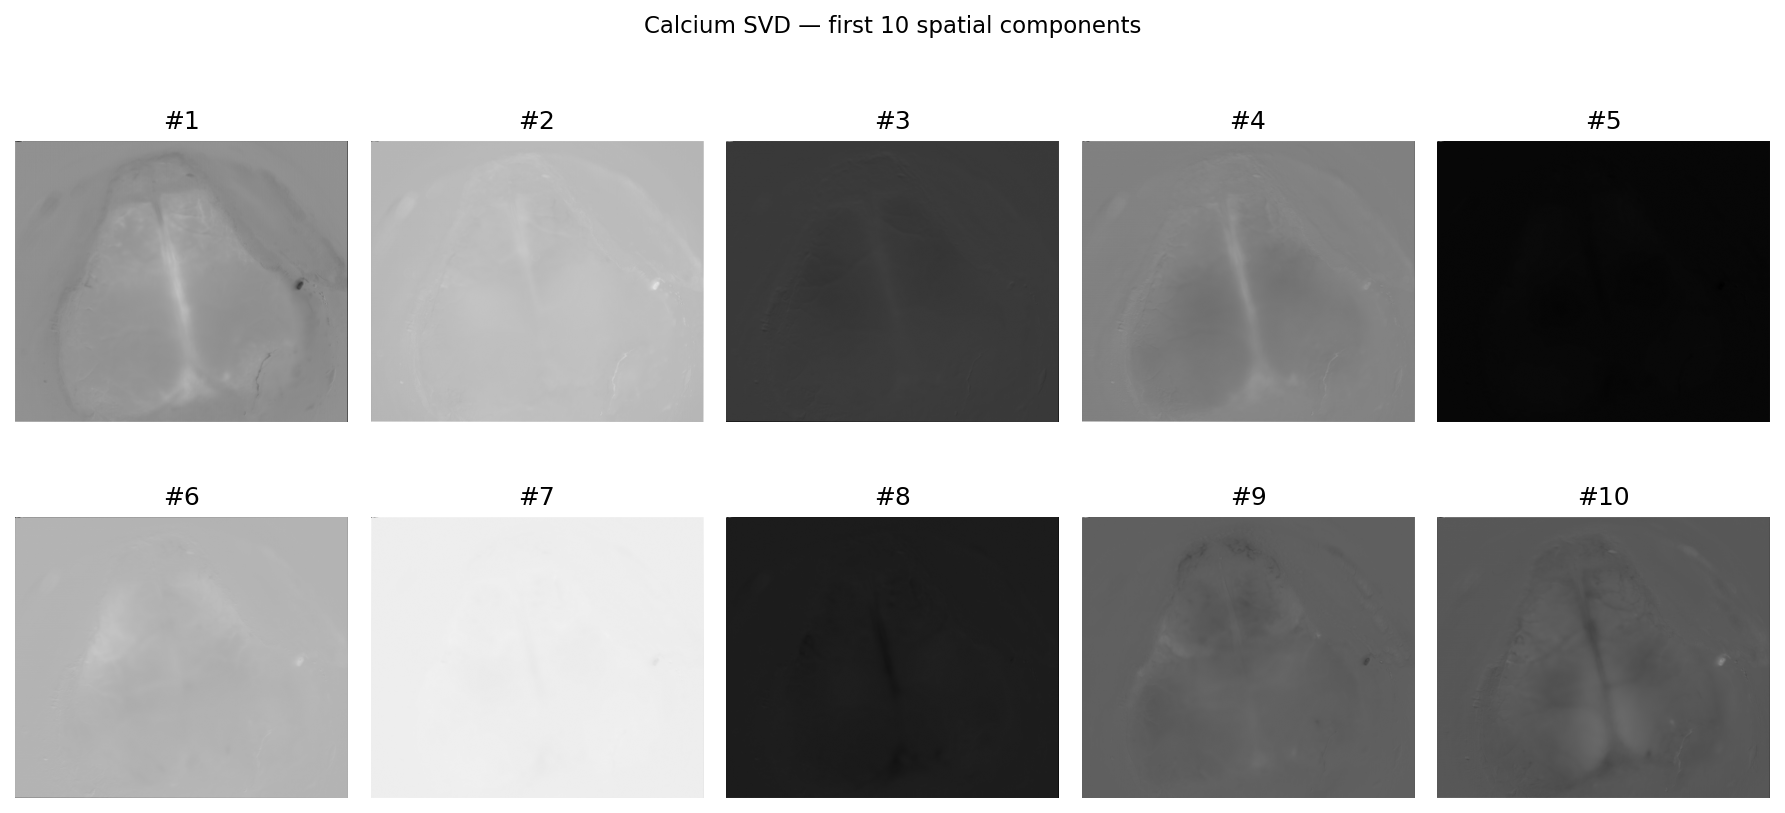

In [8]:
ps_calcium = image_segmentation["SVDTemporalComponentsCalcium"]
U_calcium  = ps_calcium["image_mask"].data[:]  # shape: (n_components, height, width)

print(f"U_calcium shape : {U_calcium.shape}  → (n_components, height, width)")

roi_ids = range(10)
fig, axes = plt.subplots(2, 5, sharex=True, sharey=True, dpi=150)
for ax, roi_id in zip(axes.flatten(), roi_ids):
    ax.imshow(U_calcium[roi_id], cmap="gray")
    ax.set_title(f"#{roi_id + 1}")
    ax.axis("off")
plt.suptitle("Calcium SVD — first 10 spatial components", fontsize=11)
plt.tight_layout()
plt.show()

### Temporal Components (SVT) <a id="temporal"></a>

Temporal SVD coefficients are stored as `RoiResponseSeries` inside the
`Fluorescence` container named `SVDTemporalComponents`.

| Series name | Description |
|---|---|
| `HaemoCorrectedSVDTemporalComponentsCalcium` | Haemodynamic-corrected calcium SVT |
| `DenoisedSVDTemporalComponentsCalcium` | Uncorrected (raw) calcium SVT |
| `DenoisedSVDTemporalComponentsIsosbestic` | Isosbestic (405 nm) SVT |

In [9]:
svd_module = ophys["SVDTemporalComponents"]

print("=== SVD Temporal Components ===")
print("-" * 100)
for _, series in svd_module.roi_response_series.items():
    print(f"Trace: {series.name}")
    print("-" * 100)
    print(f"   Description   : {series.description}")
    print(f"   Number of ROIs: {series.data.shape[1]}")
    print(f"   Duration      : {series.timestamps[-1] - series.timestamps[0]:.2f} seconds")
    print("-" * 100)

=== SVD Temporal Components ===
----------------------------------------------------------------------------------------------------
Trace: DenoisedSVDTemporalComponentsCalcium
----------------------------------------------------------------------------------------------------
   Description   : SVD temporal components (denoised/decomposed) of widefield calcium imaging from Blue light (470 nm) excitation.
   Number of ROIs: 200
   Duration      : 3999.27 seconds
----------------------------------------------------------------------------------------------------
Trace: DenoisedSVDTemporalComponentsIsosbestic
----------------------------------------------------------------------------------------------------
   Description   : SVD temporal components (denoised/decomposed) of widefield calcium imaging from Violet light (405 nm) excitation.
   Number of ROIs: 200
   Duration      : 3999.27 seconds
---------------------------------------------------------------------------------------------

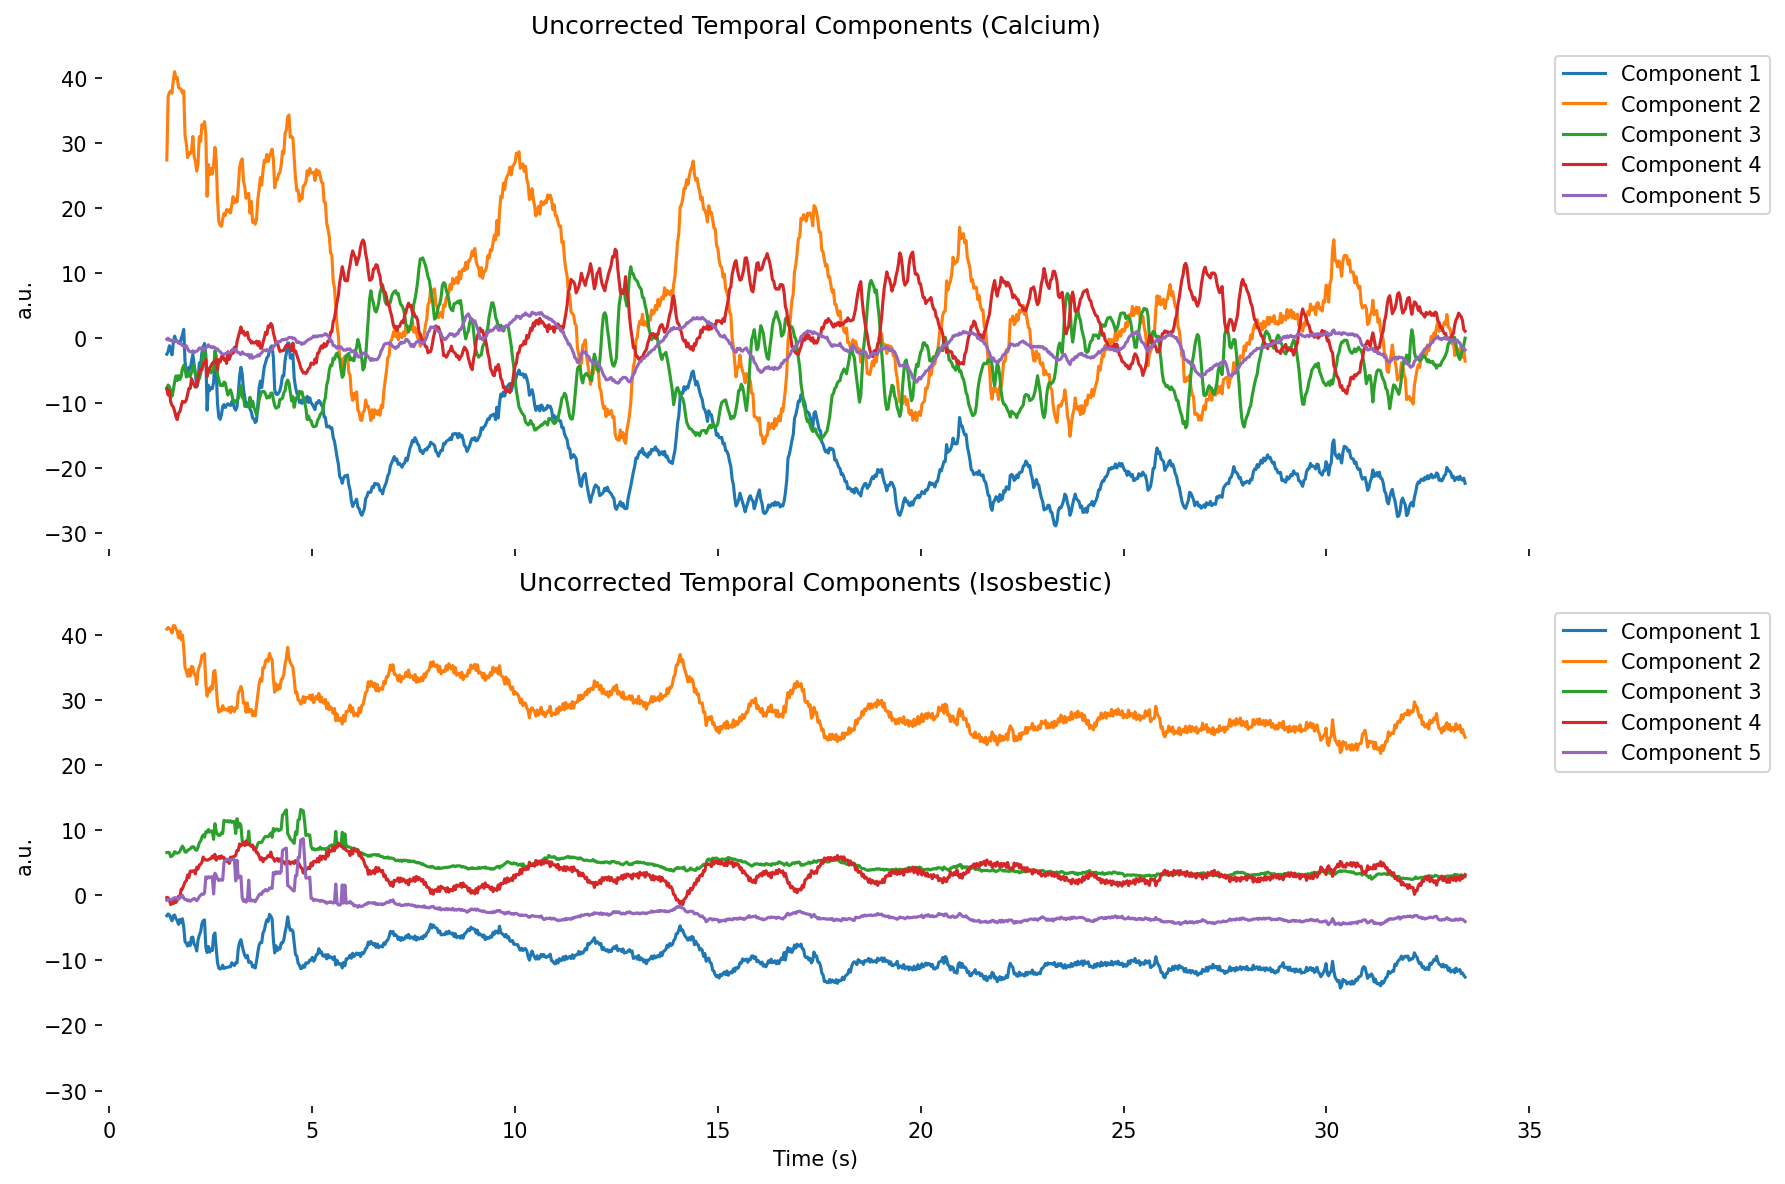

In [10]:
num_rois = 5

fig, ax = plt.subplots(2, 1, figsize=(12, 8), dpi=150, sharex=True, sharey=True)

roi_response     = svd_module["DenoisedSVDTemporalComponentsCalcium"]
roi_response_iso = svd_module["DenoisedSVDTemporalComponentsIsosbestic"]
time = roi_response.timestamps[:1000]

for roi_idx in range(num_rois):
    ax[0].plot(time, roi_response.data[:1000, roi_idx], label=f"Component {roi_idx + 1}")
ax[0].set_title("Uncorrected Temporal Components (Calcium)")
ax[0].set_ylabel("a.u.")
ax[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax[0].set_frame_on(False)

for roi_idx in range(num_rois):
    ax[1].plot(time, roi_response_iso.data[:1000, roi_idx], label=f"Component {roi_idx + 1}")
ax[1].set_title("Uncorrected Temporal Components (Isosbestic)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("a.u.")
ax[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax[1].set_frame_on(False)

plt.tight_layout()
plt.show()

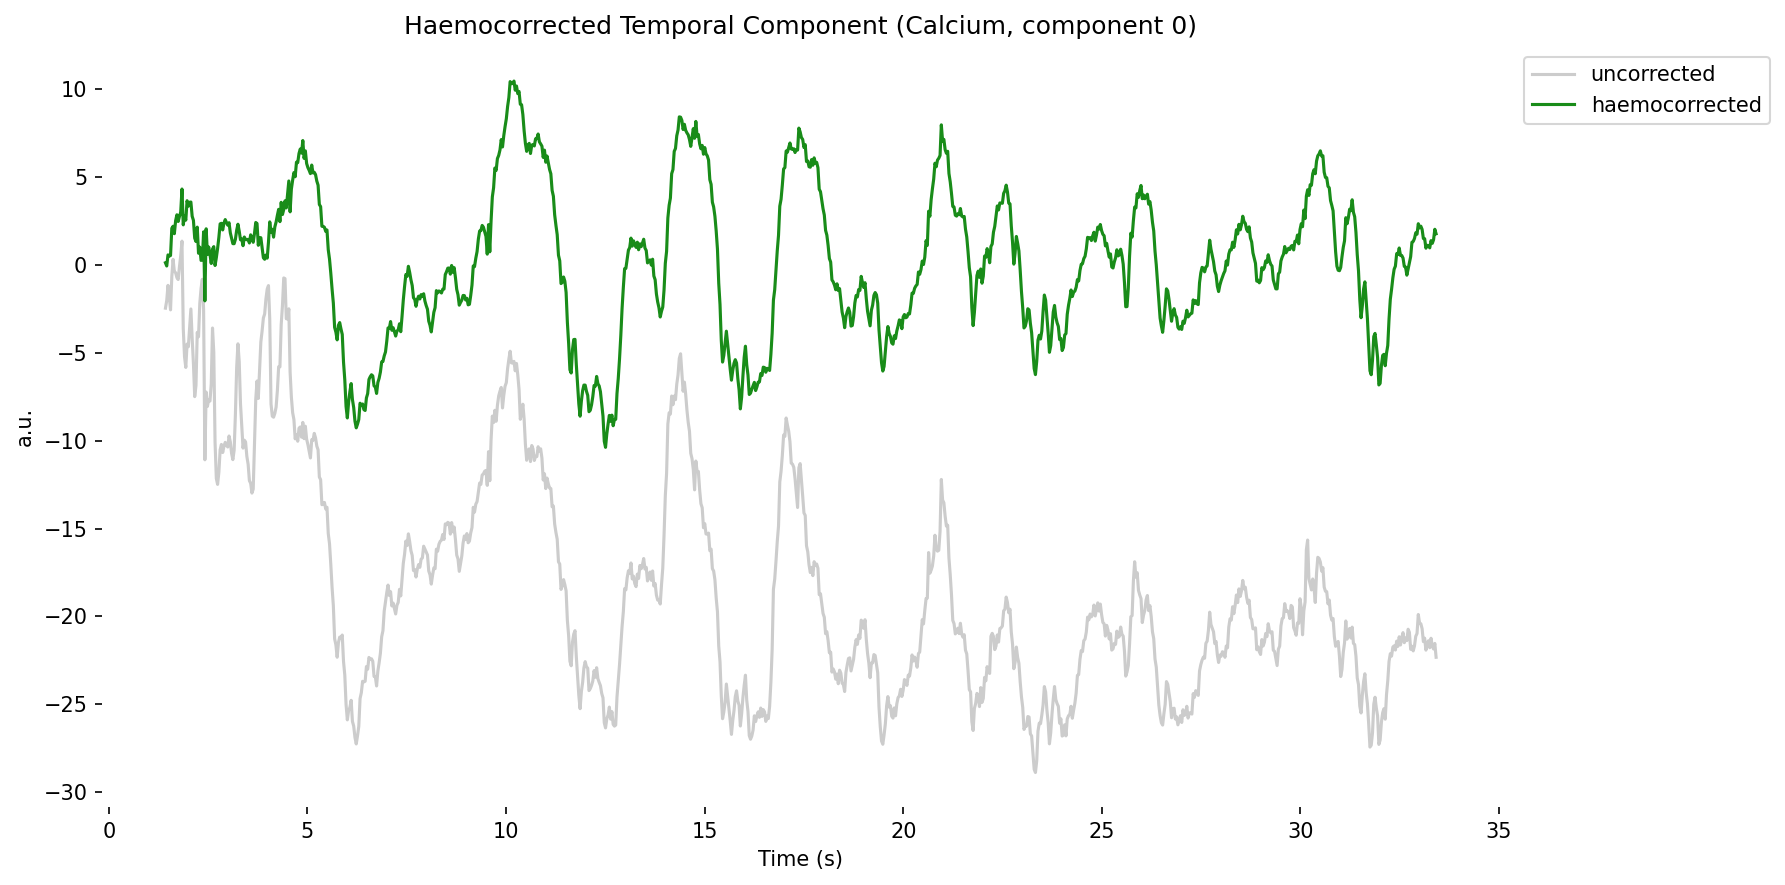

In [11]:
roi_response_dff = svd_module["HaemoCorrectedSVDTemporalComponentsCalcium"]
roi_response_raw = svd_module["DenoisedSVDTemporalComponentsCalcium"]

time = roi_response_raw.timestamps[:1000]

fig, ax = plt.subplots(dpi=150)
ax.plot(time, roi_response_raw.data[:1000, 0], label="uncorrected", color="grey", alpha=0.4)
ax.plot(time, roi_response_dff.data[:1000, 0], label="haemocorrected", color="green", alpha=0.9)
ax.set_title("Haemocorrected Temporal Component (Calcium, component 0)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("a.u.")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_frame_on(False)
plt.tight_layout()
plt.show()

### Reconstructing full-frame ΔF/F: 


In [12]:
import numpy as np
import wfield

# Spatial components (U):
# plane_segmentation["image_mask"].data has shape: (n_components, height, width)
U = nwbfile.processing["ophys"]["SVDSpatialComponents"]["SVDTemporalComponentsCalcium"].image_mask[:]
print(f"Spatial components U shape (n_components, height, width): {U.shape}")

# Haemocorrected temporal components (SVT):
# roi_response_dff.data has shape: (time, n_components)
SVT = nwbfile.processing["ophys"]["SVDTemporalComponents"]["HaemoCorrectedSVDTemporalComponentsCalcium"].data[:]
print(f"Temporal components SVT shape (time, n_components): {SVT.shape}")

# --- Prepare shapes for SVDStack ---

# wfield.SVDStack expects:
#   U_stack:  (height, width, n_components)
#   SVT_stack: (n_components, time)
U_stack = np.transpose(U, (1, 2, 0))  # (height, width, n_components)
SVT_stack = SVT.T  # (n_components, time)

print(f"U_stack shape (height, width, n_components): {U_stack.shape}")
print(f"SVT_stack shape (n_components, time):         {SVT_stack.shape}")

# --- Build the reconstructed imaging stack ---
# Resulting stack has shape: (time, height, width)
stack = wfield.SVDStack(U_stack, SVT_stack)
print(f"Reconstructed stack shape (time, height, width): {stack.shape}")

Spatial components U shape (n_components, height, width): (200, 540, 640)
Temporal components SVT shape (time, n_components): (124886, 200)
U_stack shape (height, width, n_components): (540, 640, 200)
SVT_stack shape (n_components, time):         (200, 124886)
Reconstructed stack shape (time, height, width): [124886, 540, 640]


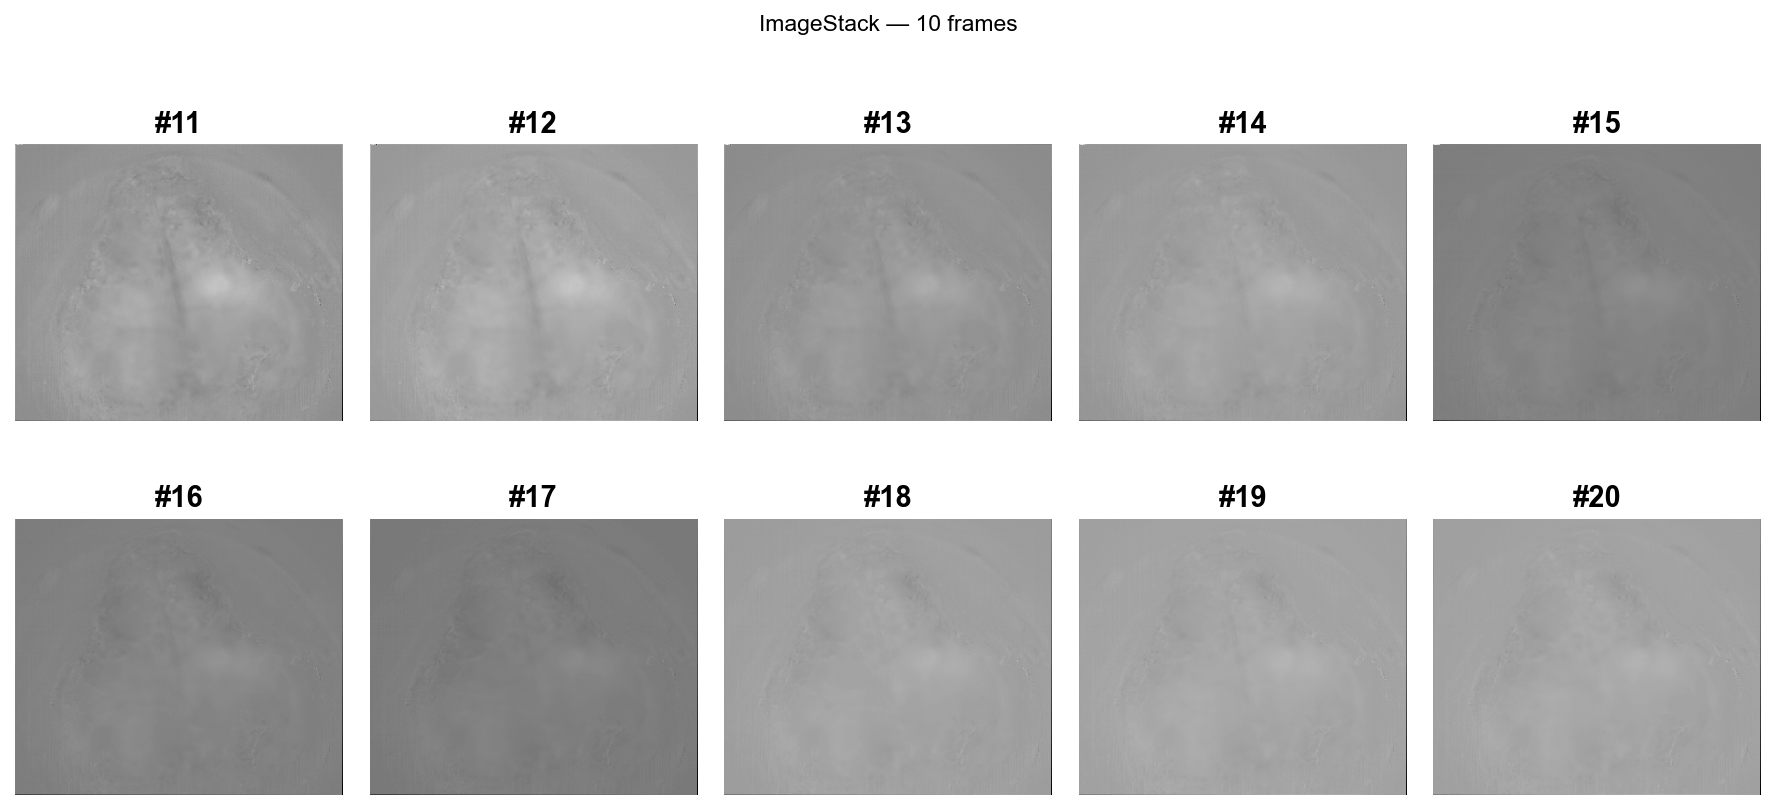

In [13]:
frames = range(10, 20)
fig, axes = plt.subplots(2, 5, sharex=True, sharey=True, dpi=150)
for ax, frame_ind in zip(axes.flatten(), frames):
    ax.imshow(stack[frame_ind], cmap="gray")
    ax.set_title(f"#{frame_ind + 1}")
    ax.axis("off")
plt.suptitle("ImageStack — 10 frames", fontsize=11)
plt.tight_layout()
plt.show()

### Summary Images <a id="summary-images"></a>

Mean fluorescence images and registration images are all stored as `GrayscaleImage`
objects in `ophys["Images"]`.

| Image name | Description |
|---|---|
| `MeanImage` | Mean frame under 470 nm (calcium) excitation |
| `MeanImageIsosbestic` | Mean frame under 405 nm (isosbestic) excitation |
| `RegisteredImage` | FOV after affine warp to atlas space |
| `AtlasProjectionImage` | 2-D Allen CCF dorsal-cortex reference |

In [14]:
summary_images = ophys["Images"]

print("=== Images container ===")
print("-" * 100)
for name, img in summary_images.images.items():
    print(f"Image: {name}")
    print("-" * 100)
    print(f"   Description: {img.description}")
    print(f"   Dimensions : {img.data[:].shape}")
    print("-" * 100)

=== Images container ===
----------------------------------------------------------------------------------------------------
Image: MeanImage
----------------------------------------------------------------------------------------------------
   Description: The mean image under Blue (470 nm) excitation across the imaging session. The dimensions are (height, width).
   Dimensions : (540, 640)
----------------------------------------------------------------------------------------------------
Image: MeanImageIsosbestic
----------------------------------------------------------------------------------------------------
   Description: The mean image under Violet (405 nm) excitation across the imaging session. The dimensions are (height, width).
   Dimensions : (540, 640)
----------------------------------------------------------------------------------------------------


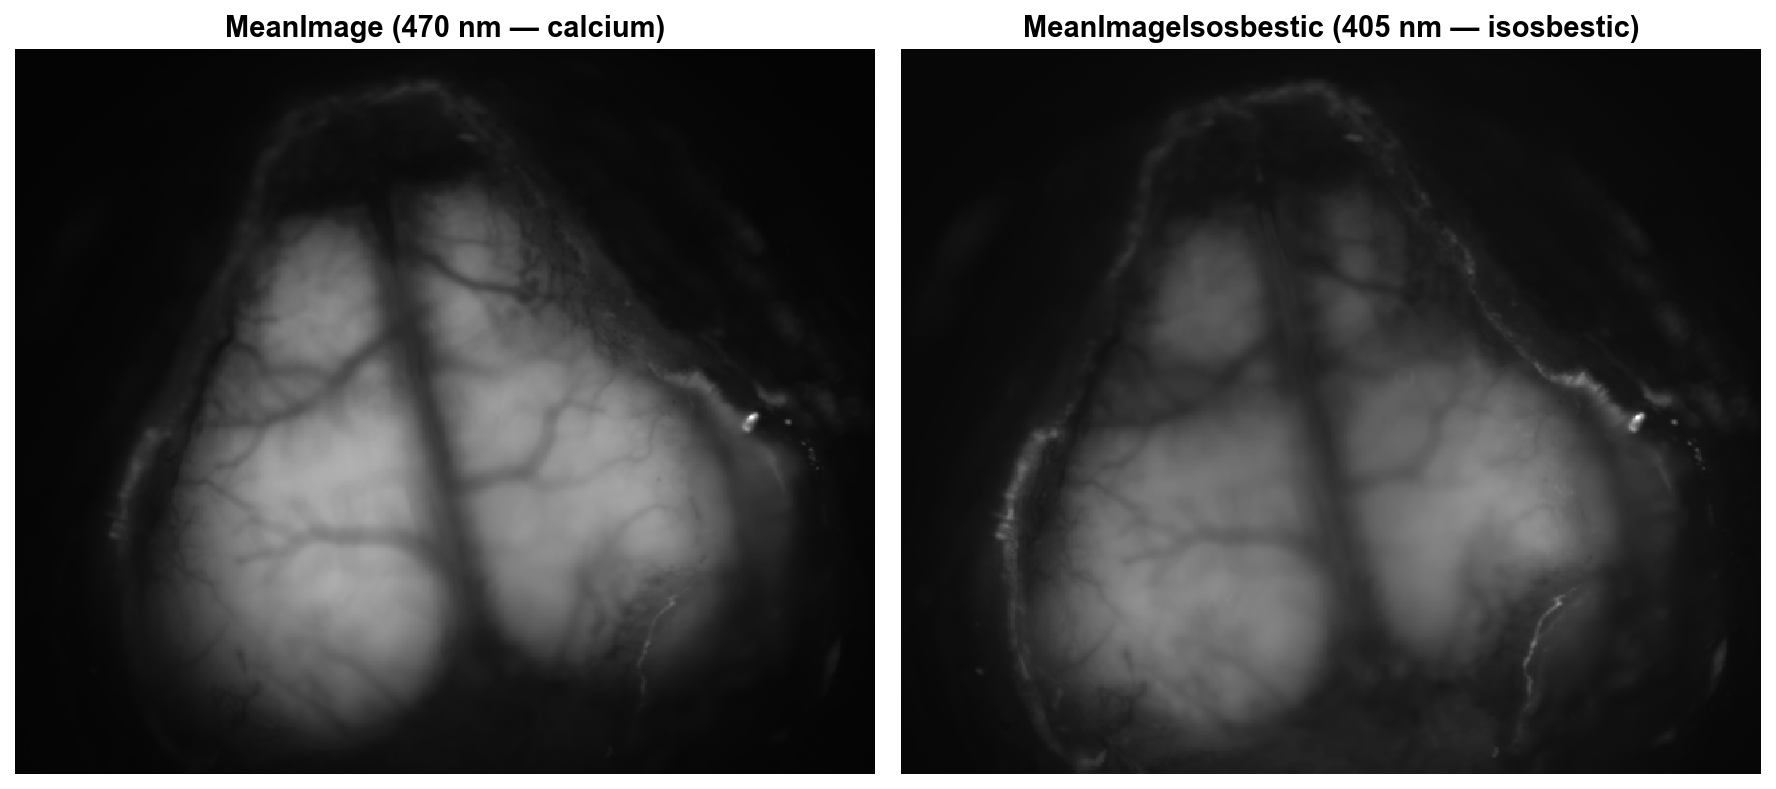

In [15]:
mean_ca  = summary_images.images["MeanImage"]
mean_iso = summary_images.images["MeanImageIsosbestic"]

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, dpi=150)
axes[0].imshow(mean_ca.data[:],  cmap="gray")
axes[0].set_title("MeanImage (470 nm — calcium)")
axes[0].axis("off")
axes[1].imshow(mean_iso.data[:], cmap="gray")
axes[1].set_title("MeanImageIsosbestic (405 nm — isosbestic)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

---

# 4. Behavior <a id="behavior"></a>

## Epochs (Task vs Passive) <a id="epochs"></a>

In [16]:
nwbfile.epochs

## Trials <a id="trials"></a>

In [17]:
trials_df = nwbfile.trials[:]
trials_df[:].head()

,start_time,stop_time,quiescence_period,gabor_stimulus_onset_time,auditory_cue_time,wheel_movement_onset_time,choice_registration_time,feedback_time,gabor_stimulus_offset_time,gabor_stimulus_contrast,gabor_stimulus_side,mouse_wheel_choice,is_mouse_rewarded,reward_volume_uL,probability_left,block_type,block_index
id,,,,,,,,,,,,,,,,,
0,9.005300,11.378369,0.408739,9.611700,9.527333,9.547467,9.824192,9.824300,10.878233,6.25,right,counter_clockwise,True,1.5,0.5,unbiased,0
1,11.970433,15.512113,0.688284,12.711600,12.712667,12.731467,12.956938,12.957700,15.012033,25.00,left,counter_clockwise,False,0.0,0.5,unbiased,0
2,16.036867,19.412643,0.539380,16.628967,16.630100,16.649467,16.858258,16.859167,18.912533,6.25,left,counter_clockwise,False,0.0,0.5,unbiased,0
3,19.939600,37.414679,0.554322,20.545967,20.546867,25.873467,35.870011,35.870100,36.914533,0.00,right,counter_clockwise,True,1.5,0.5,unbiased,0
4,37.943833,41.348408,0.580240,38.564500,38.565500,38.588467,38.798427,38.799200,40.848300,0.00,left,counter_clockwise,False,0.0,0.5,unbiased,0


In [18]:
nwbfile.processing.keys()

dict_keys(['lick_times', 'motion_energy', 'ophys', 'pose_estimation', 'pupil', 'wheel'])

## Lick Times <a id="lick-times"></a>

Lick events detected from video-based tongue pose estimation are stored as an `Events` object in the `lick_times` processing module.

Access example
```python
lick_events = nwbfile.processing["lick_times"]["EventsLickTimes"]
timestamps = lick_events.timestamps[:]
```

In [19]:
lick_events = nwbfile.processing["lick_times"]["EventsLickTimes"]

print("=== LICK TIMES ===")
print(f"Description: {lick_events.description}\n")
lick_times = lick_events.timestamps[:]
print(f"Number of licks: {len(lick_times)}")
print(f"Session duration with licks: {lick_times[-1] - lick_times[0]:.2f} s")
print(f"Mean lick rate: {len(lick_times) / (lick_times[-1] - lick_times[0]):.2f} licks/s")

=== LICK TIMES ===
Description: Lick event timestamps detected from tongue pose estimation (Lightning Pose). Detection algorithm: frame-to-frame position changes in tongue landmarks (tongue_end_l_x, tongue_end_l_y, tongue_end_r_x, tongue_end_r_y) are computed, and frames where any coordinate changes by more than std(diff)/4 are marked as lick events. If left and right camera data exist, the licks detected from both cameras are combined.

Number of licks: 24506
Session duration with licks: 3945.62 s
Mean lick rate: 6.21 licks/s


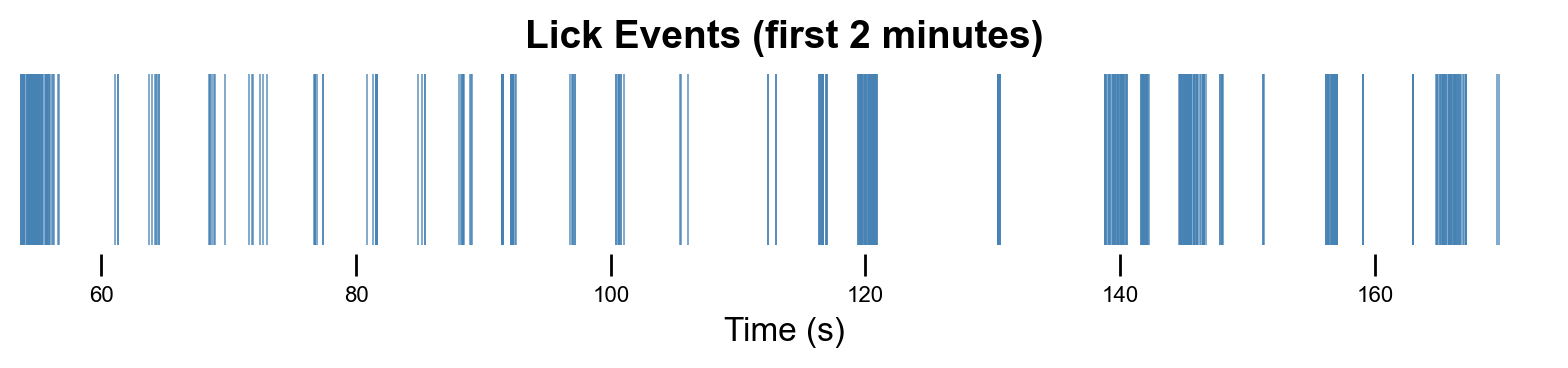

In [20]:
# --- Plot 1: lick events as a raster over a 2-minute window ---
window_start, window_end = lick_times[0], lick_times[0] + 120.0
mask = (lick_times >= window_start) & (lick_times <= window_end)
lick_window = lick_times[mask]

fig, ax = plt.subplots(figsize=(8, 2), dpi=200)

# Raster
ax.vlines(lick_window, 0, 1, linewidth=0.6, color="steelblue", alpha=0.8)
ax.set_xlim(window_start, window_end)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title("Lick Events (first 2 minutes)")
ax.set_frame_on(False)

plt.tight_layout()
plt.show()

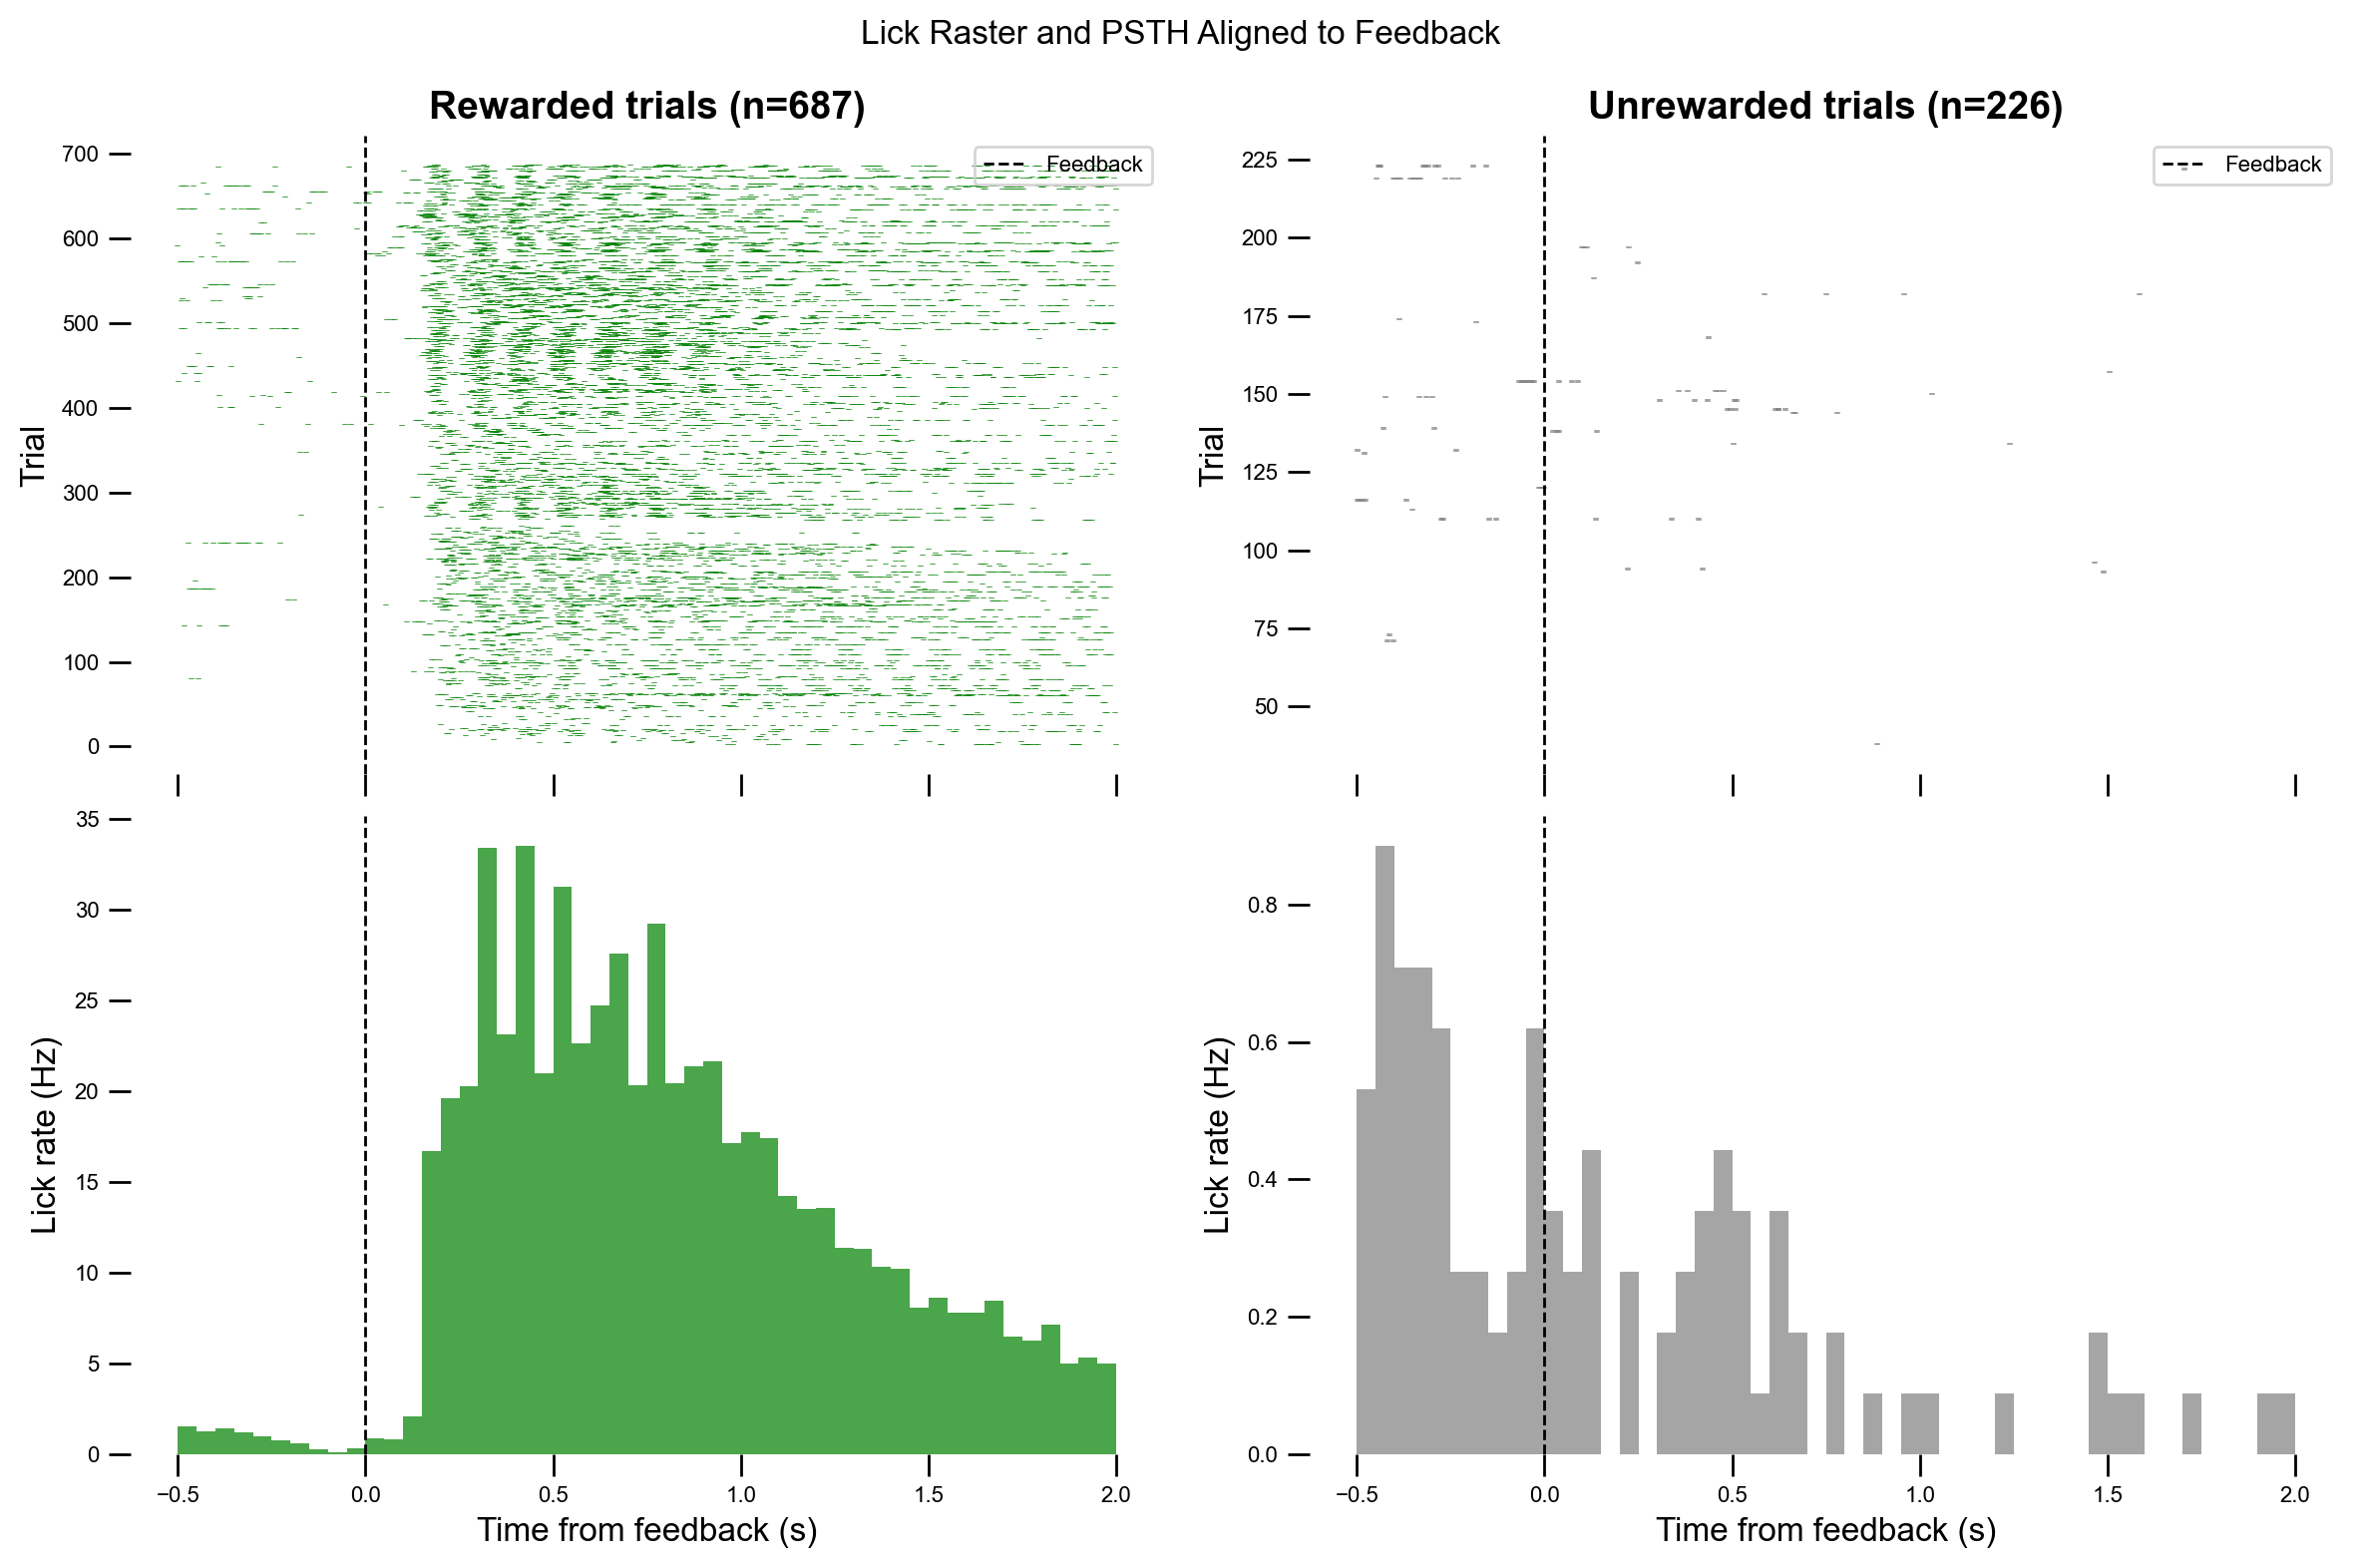

In [21]:
# Trial-aligned lick raster + PSTH around feedback time (IBL-style)
pre_time = 0.5   # s before feedback
post_time = 2.0  # s after feedback
bin_size = 0.05  # 50 ms bins

feedback_times = nwbfile.trials["feedback_time"][:]
is_rewarded = nwbfile.trials["is_mouse_rewarded"][:]

bins = np.arange(-pre_time, post_time + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2

raster_rewarded, raster_unrewarded = [], []
psth_rewarded = np.zeros(len(bins) - 1)
psth_unrewarded = np.zeros(len(bins) - 1)

for t_fb, rewarded in zip(feedback_times, is_rewarded):
    rel = lick_times[(lick_times >= t_fb - pre_time) & (lick_times <= t_fb + post_time)] - t_fb
    counts, _ = np.histogram(rel, bins=bins)
    if rewarded:
        raster_rewarded.append(rel)
        psth_rewarded += counts
    else:
        raster_unrewarded.append(rel)
        psth_unrewarded += counts

n_rew = len(raster_rewarded) or 1
n_unrew = len(raster_unrewarded) or 1
psth_rewarded = psth_rewarded / (n_rew * bin_size)
psth_unrewarded = psth_unrewarded / (n_unrew * bin_size)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200, sharex=True)

for col, (raster, psth, label, color) in enumerate([
    (raster_rewarded, psth_rewarded, "Rewarded", "green"),
    (raster_unrewarded, psth_unrewarded, "Unrewarded", "gray"),
]):
    # Raster
    for trial_idx, trial_lick_times in enumerate(raster):
        axes[0, col].vlines(trial_lick_times, trial_idx - 0.4, trial_idx + 0.4,
                            linewidth=2, color=color, alpha=0.7)
    axes[0, col].axvline(0, color="black", linewidth=1, linestyle="--", label="Feedback")
    axes[0, col].set_ylabel("Trial")
    axes[0, col].set_title(f"{label} trials (n={len(raster)})")
    axes[0, col].legend(loc="upper right", fontsize=8)
    axes[0, col].set_frame_on(False)

    # PSTH
    axes[1, col].bar(bin_centers, psth, width=bin_size, color=color, alpha=0.7, edgecolor="none")
    axes[1, col].axvline(0, color="black", linewidth=1, linestyle="--")
    axes[1, col].set_xlabel("Time from feedback (s)")
    axes[1, col].set_ylabel("Lick rate (Hz)")
    axes[1, col].set_frame_on(False)

fig.suptitle("Lick Raster and PSTH Aligned to Feedback", fontsize=12)
plt.tight_layout()
plt.show()

## Pupil <a id="pupil"></a>

Pupil diameter measurements from video-based eye tracking are stored as `TimeSeries` in the `pupil` processing module. Each camera contributes a raw and a smoothed diameter trace (in pixels).

| Series name | Content |
|---|---|
| `LeftPupilDiameter` | Raw left-camera pupil diameter |
| `LeftPupilDiameterSmoothed` | Temporally smoothed left-camera diameter |
| `RightPupilDiameter` | Raw right-camera pupil diameter |
| `RightPupilDiameterSmoothed` | Temporally smoothed right-camera diameter |

Access example
```python
pupil_module = nwbfile.processing["pupil"]
left_raw = pupil_module["LeftPupilDiameter"]
timestamps = left_raw.timestamps[:]
diameter  = left_raw.data[:]
```

In [22]:
pupil_module = nwbfile.processing["pupil"]

print("=== PUPIL PROCESSING MODULE ===")
print("-" * 80)
for name, ts in pupil_module.data_interfaces.items():
    print(f"  {name}")
    print(f"    Description: {ts.description}")
    print(f"    Samples: {ts.data.shape[0]}  |  Unit: {ts.unit}")
    print("-" * 80)

=== PUPIL PROCESSING MODULE ===
--------------------------------------------------------------------------------
  LeftPupilDiameter
    Description: Raw pupil diameter estimated from pose tracking keypoints around the pupil boundary. Multiple diameter estimates are computed: vertical (top-bottom distance), horizontal (left-right distance), and circular fits from other keypoint pairs. The final value is the median of these estimates, providing robustness against individual tracking errors.
    Samples: 239237  |  Unit: px
--------------------------------------------------------------------------------
  LeftPupilDiameterSmoothed
    Description: Smoothed pupil diameter. This version has been temporally smoothed and interpolated over frames with missing or low-confidence keypoint detections. Useful for analyses where smooth trajectories are preferred over frame-by-frame accuracy.
    Samples: 239237  |  Unit: px
---------------------------------------------------------------------------

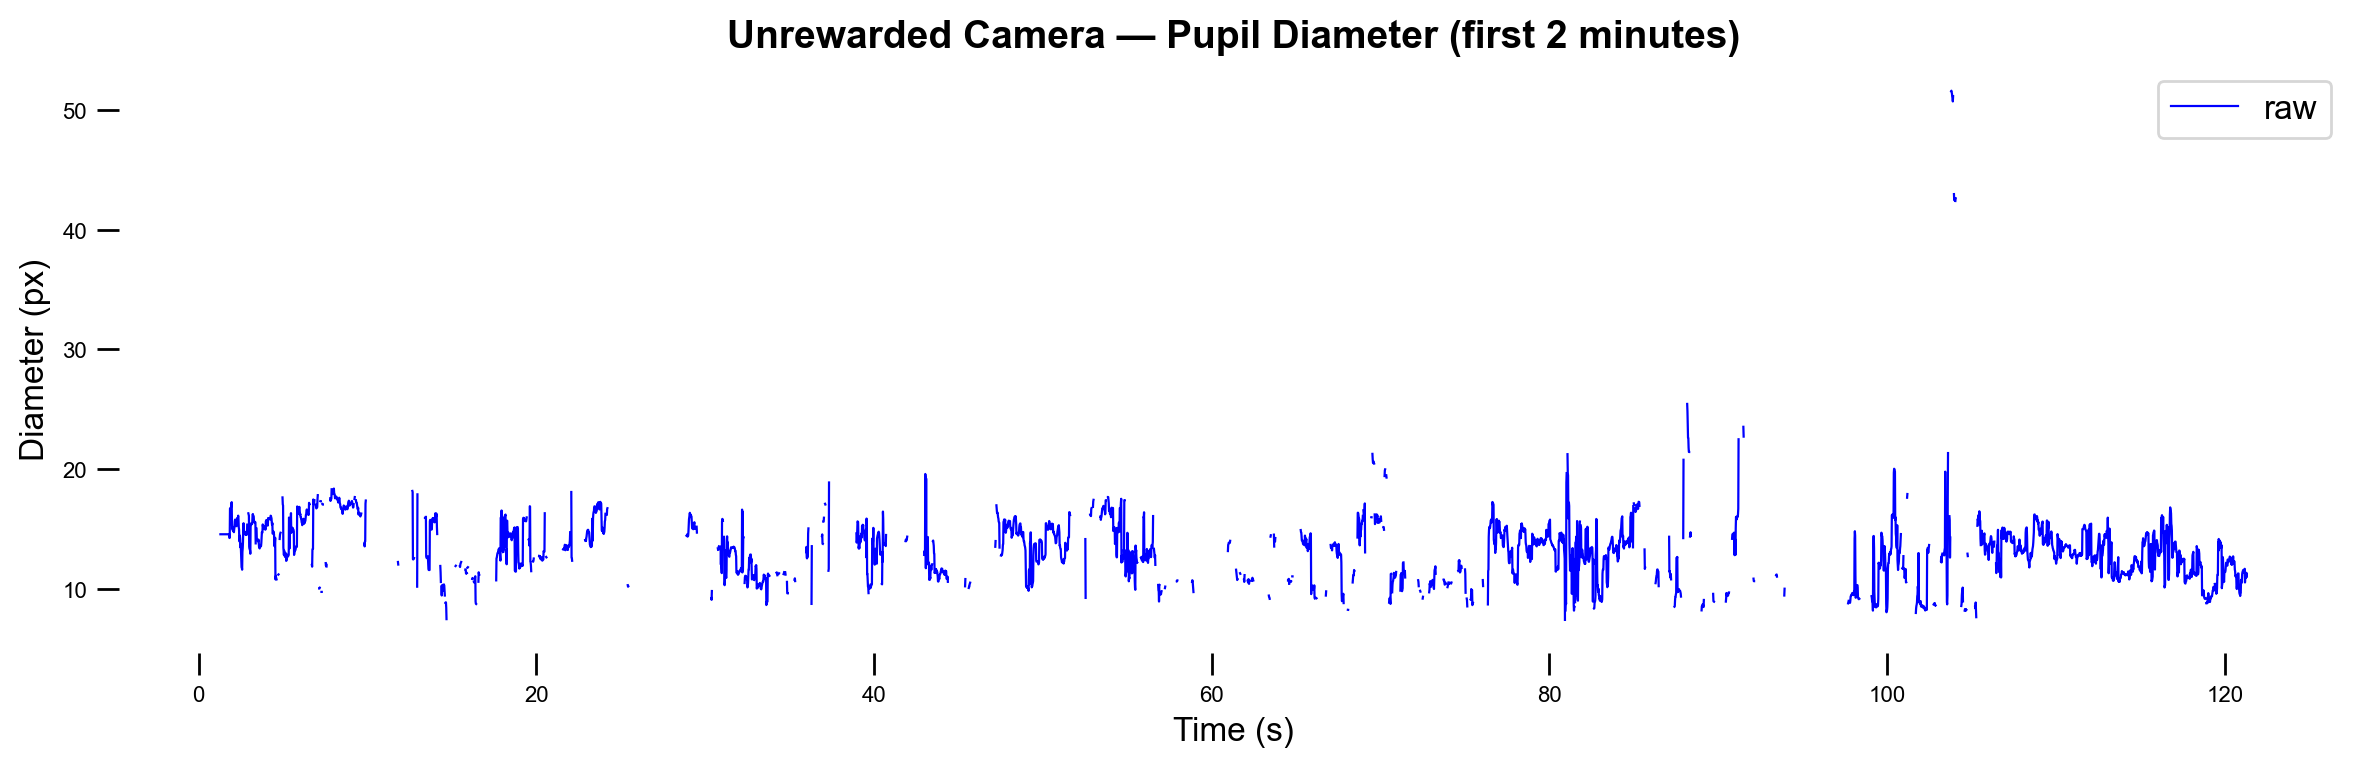

In [23]:
# Plot raw vs smoothed pupil diameter for each available camera over a 2-minute window
fig, axes = plt.subplots(figsize=(12, 4), dpi=200)

raw_ts = pupil_module["LeftPupilDiameter"]

t = raw_ts.timestamps[:]
window_mask = (t >= t[0]) & (t <= t[0] + 120.0)

t_win = t[window_mask]
raw_win = raw_ts.data[window_mask]

axes.plot(t_win, raw_win, color="blue", linewidth=0.8, label="raw")
axes.set_title(f"{label} Camera — Pupil Diameter (first 2 minutes)")
axes.set_xlabel("Time (s)")
axes.set_ylabel(f"Diameter ({raw_ts.unit})")
axes.legend(loc="upper right")
axes.set_frame_on(False)

plt.tight_layout()
plt.show()

## ROI Motion Energy <a id="motion-energy"></a>

In [24]:
print("=== MOTION ENERGY PROCESSING MODULE ===\n")
motion_energy_series = []
for name, proc in nwbfile.processing["motion_energy"].items():
    print("-" * 100)
    print(f"{name} - {proc.description}: ")
    print("-" * 100)
    motion_energy_series.append(name)

=== MOTION ENERGY PROCESSING MODULE ===

----------------------------------------------------------------------------------------------------
BodyCameraMotionEnergy - Motion energy calculated for a region of the body camera video. ROI dimensions: 207 pixels wide, 210 pixels tall, top-left corner at (138, 44).

Calculation: For each frame, pixel intensity differences are computed between frame N and frame N+2 (default offset). The Euclidean norm (L2) of differences is summed across all ROI pixels, then min-max normalized to [0, 1] range. Higher values indicate more movement within the ROI.

CAUTION: Video loading libraries may use different axis conventions. When loading with cv2 in Python, x and y axes are flipped. The region then becomes [44:254, 138:345].: 
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
LeftCameraMotionEnergy - Mot

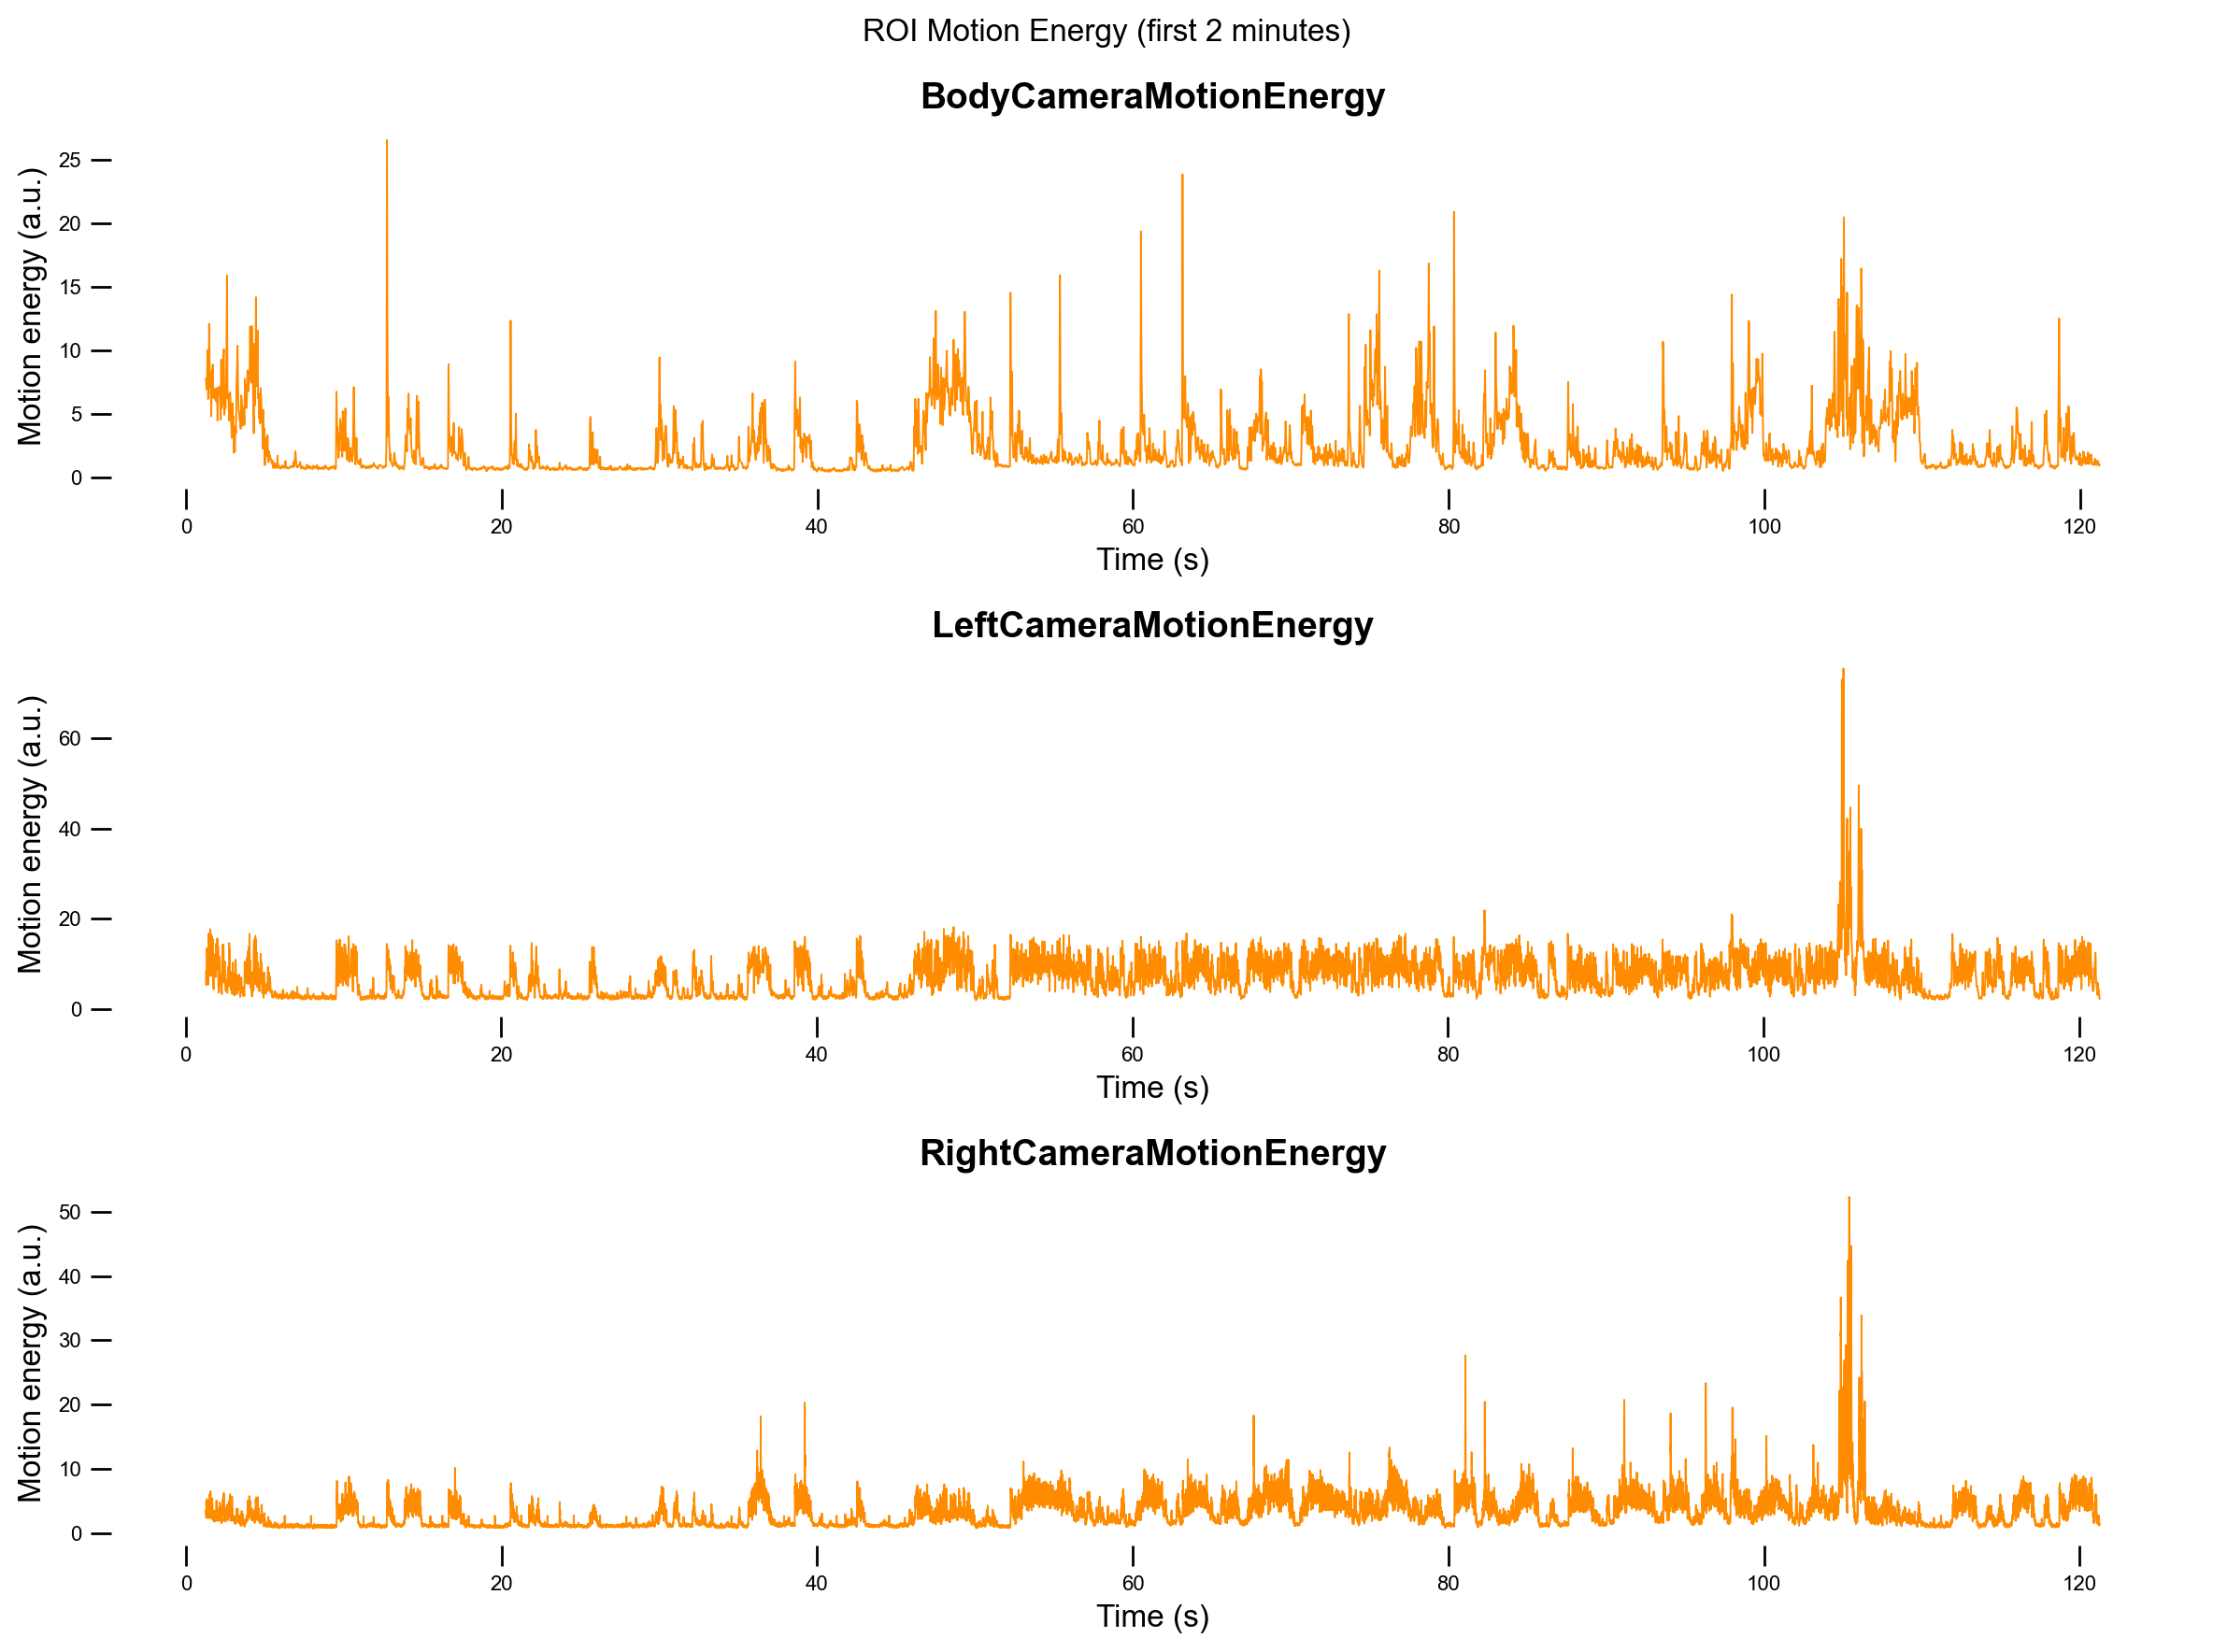

In [25]:
motion_energy_module = nwbfile.processing["motion_energy"]
me_names = list(motion_energy_module.data_interfaces.keys())

fig, axes = plt.subplots(len(me_names), 1, figsize=(12, 3 * len(me_names)), dpi=200, squeeze=False, sharex=False)

for ax, name in zip(axes[:, 0], me_names):
    ts = motion_energy_module[name]
    t = ts.timestamps[:]
    window_mask = (t >= t[0]) & (t <= t[0] + 120.0)
    t_win = t[window_mask]
    data_win = ts.data[window_mask]

    ax.plot(t_win, data_win, color="darkorange", linewidth=0.7)
    ax.set_title(name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Motion energy (a.u.)")
    ax.set_frame_on(False)

plt.suptitle("ROI Motion Energy (first 2 minutes)", fontsize=12)
plt.tight_layout()
plt.show()

## Wheel <a id="wheel"></a>

In [26]:
print("=== WHEEL PROCESSING MODULE ===\n")
motion_energy_series = []
for name, proc in nwbfile.processing["wheel"].items():
    if "CompassDirection" in name:
        print("-" * 100)
        print(f"{name}: ")
        print("-" * 100)
        for ss_name, ss in proc.spatial_series.items():
            print(f"\t{ss_name} - {ss.description}")
    elif "Intervals" in name:
        print("-" * 100)
        print(f"{name} - {proc.description}: ")
        display(proc.to_dataframe().head(5))  # Display first 5 rows
        print("-" * 100)
    else:
        print("-" * 100)
        print(f"{name} - {proc.description}: ")
        print("-" * 100)
        motion_energy_series.append(name)

=== WHEEL PROCESSING MODULE ===

----------------------------------------------------------------------------------------------------
WheelAccelerationSmoothed - Wheel angular acceleration derived from velocity (WheelVelocitySmoothed). Computed as the second derivative of the smoothed position signal.: 
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
WheelPosition - Absolute unwrapped wheel angle recorded from a quadrature rotary encoder. The wheel (diameter 6.2 cm) is positioned under the mouse's forepaws and serves as the primary behavioral input device for reporting perceptual decisions. Sampling is event-driven: timestamps are recorded only when the wheel moves (i.e., when the encoder generates TTL edges), resulting in irregular inter-sample intervals. The encoder uses X4 decoding of two 90-degree phase-shifted channels, providing

,start_time,stop_time,peak_amplitude
id,,,
0,0.292967,3.767967,-8.291663
1,4.574967,5.145967,-0.506395
2,9.547967,10.127967,-0.616196
3,10.678967,10.981967,-0.272643
4,12.731967,13.014967,-0.301509


----------------------------------------------------------------------------------------------------


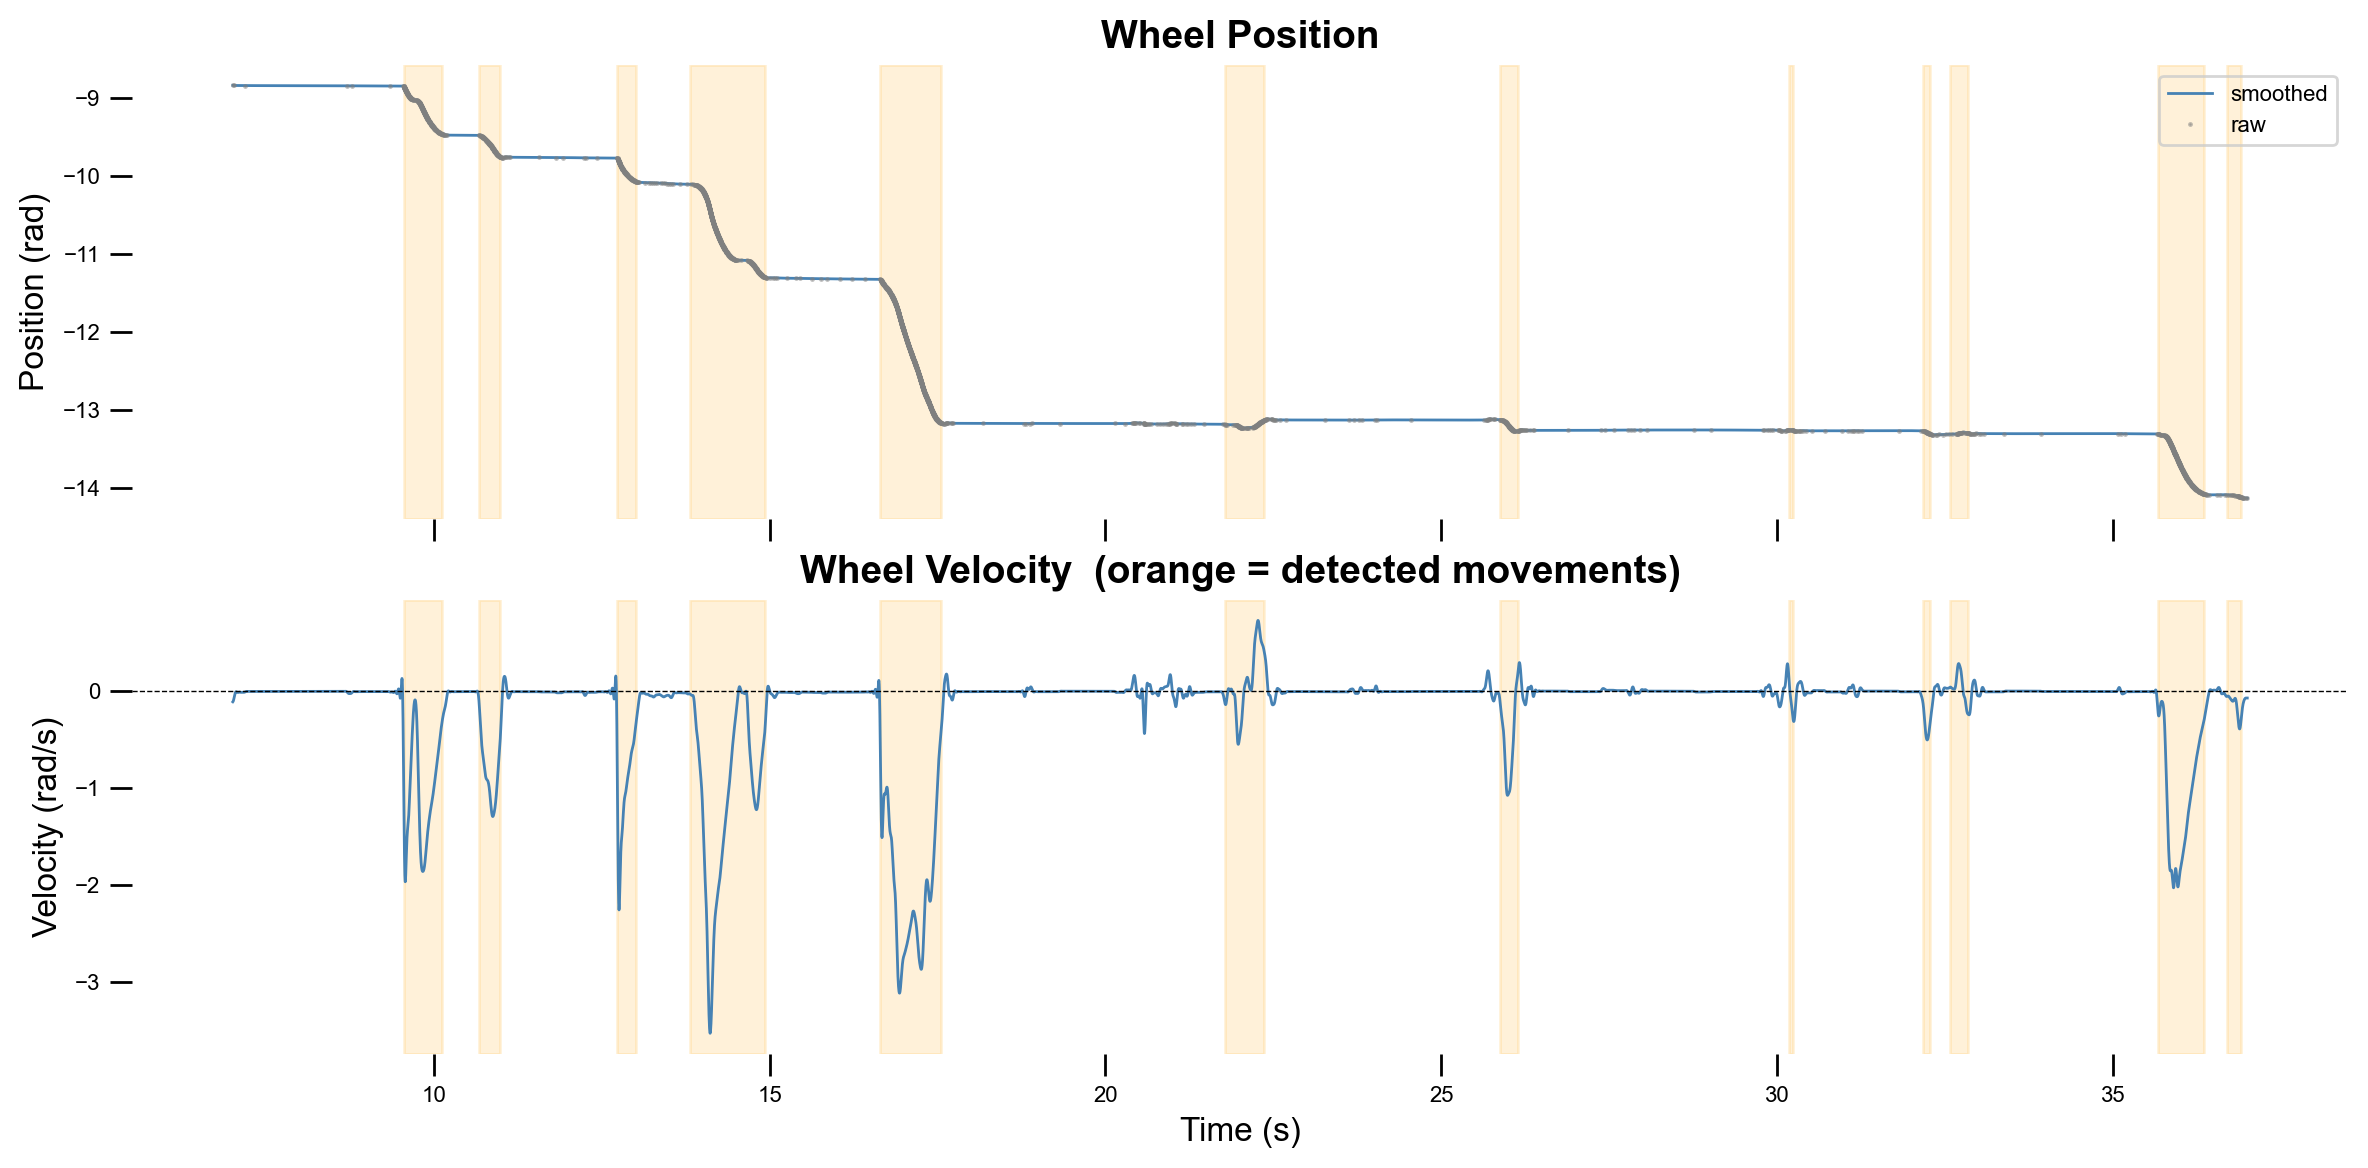

In [27]:
wheel_module = nwbfile.processing["wheel"]

# Load smoothed position and velocity (1000 Hz uniform grid, stored with rate+starting_time)
pos_smooth = wheel_module["WheelPositionSmoothed"]
vel_smooth = wheel_module["WheelVelocitySmoothed"]
movements = wheel_module["WheelMovementIntervals"]

# Reconstruct timestamps for rate-based series
n_smooth = pos_smooth.data.shape[0]
t_smooth = pos_smooth.starting_time + np.arange(n_smooth) / pos_smooth.rate
p_smooth = pos_smooth.data[:]
v_smooth = vel_smooth.data[:]

# Raw position uses irregular timestamps (event-driven encoder edges)
pos_raw = wheel_module["WheelPosition"]
t_raw = pos_raw.timestamps[:]
p_raw = pos_raw.data[:]

# Show a 30-second window starting just before the first trial
trial_start = float(nwbfile.trials["start_time"][0])
t_win_start = trial_start - 2.0
t_win_end = trial_start + 28.0

smooth_mask = (t_smooth >= t_win_start) & (t_smooth <= t_win_end)
raw_mask = (t_raw >= t_win_start) & (t_raw <= t_win_end)

# Movement intervals in window
mov_df = movements.to_dataframe()
mov_in_win = mov_df[(mov_df["start_time"] >= t_win_start) & (mov_df["stop_time"] <= t_win_end)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=200, sharex=True)

# --- Top: wheel position ---
axes[0].plot(t_smooth[smooth_mask], p_smooth[smooth_mask], color="steelblue", linewidth=1.0, label="smoothed")
axes[0].plot(t_raw[raw_mask], p_raw[raw_mask], ".", color="gray", markersize=1.5, alpha=0.5, label="raw")
for _, row in mov_in_win.iterrows():
    axes[0].axvspan(row["start_time"], row["stop_time"], alpha=0.15, color="orange")
axes[0].set_ylabel("Position (rad)")
axes[0].set_title("Wheel Position")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_frame_on(False)

# --- Bottom: smoothed velocity with movement intervals ---
axes[1].plot(t_smooth[smooth_mask], v_smooth[smooth_mask], color="steelblue", linewidth=1.0)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
for _, row in mov_in_win.iterrows():
    axes[1].axvspan(row["start_time"], row["stop_time"], alpha=0.15, color="orange")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Velocity (rad/s)")
axes[1].set_title("Wheel Velocity  (orange = detected movements)")
axes[1].set_frame_on(False)

plt.tight_layout()
plt.show()

## Pose Estimation <a id="pose-estimation"></a>

Pose estimation from video using DeepLabCut.

In [28]:
pose_estimation_module = nwbfile.processing["pose_estimation"]
pose_estimation_module

Data type,float64
Shape,"(119964, 2)"
Array size,1.83 MiB
Chunk shape,"(119964, 2)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),1919424
Compressed size (bytes),851105
Compression ratio,2.255214104017718
Data type,float64
Shape,"(119964,)"


In [29]:
left_camera = pose_estimation_module["LeftCamera"]
left_camera

Data type,float64
Shape,"(239237, 2)"
Array size,3.65 MiB
Chunk shape,"(239237, 2)"
Compression,gzip
Compression opts,4
Uncompressed size (bytes),3827792
Compressed size (bytes),1618331
Compression ratio,2.3652713814417448
Data type,float64
Shape,"(239237,)"


In [30]:
# TODO: pose estimation visualization (needs video_s3_urls)
# from ibl_to_nwb.widgets import NWBPoseEstimationWidget
#
# NWBPoseEstimationWidget(
#     nwbfile=nwbfile,
#     video_urls=video_s3_urls,
#     camera_to_video_key={
#         "LeftCamera": "VideoLeftCamera",
#         "BodyCamera": "VideoBodyCamera",
#         "RightCamera": "VideoRightCamera",
#     },
# )

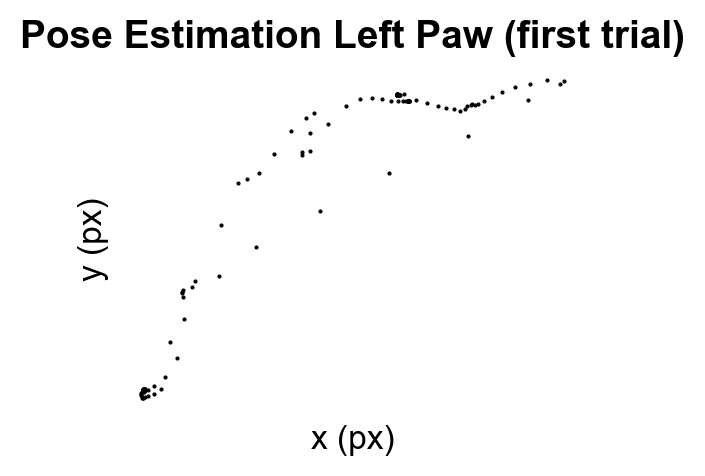

In [31]:
import numpy as np

pose_estimation_series_left_paw = left_camera.pose_estimation_series["PoseEstimationSeriesLeftPaw"]

data = np.array(pose_estimation_series_left_paw.data)
timestamps = np.array(pose_estimation_series_left_paw.timestamps)

trial_start = nwbfile.trials["start_time"][0]
trial_stop = nwbfile.trials["stop_time"][0]

# Filter by timestamps (robust; no need for an external rate)
mask = (timestamps >= trial_start) & (timestamps <= trial_stop)
xy = data[mask]

x = xy[:, 0]
y = xy[:, 1]

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)
ax.plot(x, y, ".", markersize=1)

ax.set_xlabel(f"x ({pose_estimation_series_left_paw.unit})")
ax.set_ylabel(f"y ({pose_estimation_series_left_paw.unit})")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Pose Estimation Left Paw (first trial)")

ax.set_frame_on(False)
ax.set_aspect("equal", adjustable="box")
plt.show()